In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### tp5_tp6. (2da parte)
# Gráficos de línea, barra, dispersión, boxplot usando Python. Manejo de Outiers. Crear Diccionarios.

In [3]:
tabla5=pd.read_csv(r'C:\Users\Usuario\Documents\Python Scripts\pop_housing_censuses.csv' )
t5=pd.DataFrame(tabla5)
t5

,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample
0,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_24,Total,0.302885,0.178212,0.588380,66484.0
1,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_29,Total,0.312607,0.153185,0.490024,91575.0
2,year,1970,country,ARG,IPUMS,jefa_ch_PHC,Total,Total,Total,Total,Total,Total,0.165427,0.106774,0.645448,121099.0
3,year,1970,country,ARG,IPUMS,pobfem_ci_PHC,Total,Total,Total,Total,Total,Total,0.503334,0.073178,0.145387,466827.0
4,year,1970,country,ARG,IPUMS,miembro6_ch_PHC,Total,Total,Total,Total,Total,Total,0.301808,0.131912,0.437070,121100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0


In [4]:
# Analisis exploratio
#++++++++++++++++++++
t5.dtypes
# se: Standard error, cv: coefficent of variation mu/x

iddate              object
year                 int64
idgeo               object
isoalpha3           object
source              object
indicator           object
area                object
quintile            object
sex                 object
education_level     object
age                 object
ethnicity           object
value              float64
se                 float64
cv                 float64
sample             float64
dtype: object

In [5]:
# indicadores estadisticos
t5[["year","sample"]].describe()

,year,sample
count,279229.000000,2.790990e+05
mean,1994.185815,3.191302e+05
std,15.309689,1.089746e+06
min,1960.000000,1.000000e+00
25%,1982.000000,5.532000e+03
50%,2000.000000,2.906000e+04
75%,2005.000000,1.384680e+05
max,2015.000000,2.478972e+07


In [6]:
# Cantidad de valores ausentes por atributo
t5.isna().sum().sort_values()

iddate               0
year                 0
idgeo                0
isoalpha3            0
source               0
indicator            0
area                 0
quintile             0
sex                  0
education_level      0
age                  0
ethnicity            0
value                0
sample             130
se                 447
cv                 577
dtype: int64

In [7]:
# tabla de frecuencia de una variable categórica
# Contar la cantidad de encuestados por nuvel educativo y por sexo.
tf=t5[['education_level','sex']].value_counts()
tf

education_level  sex  
Total            Total    97184
                 men      87213
                 women    83797
primary          Total     1626
                 women     1626
                 men       1625
secondary        Total     1233
                 men       1233
                 women     1232
tertiary         Total      822
                 women      820
                 men        818
Name: count, dtype: int64

In [8]:
t6=t5[["year","isoalpha3","source","area","sex","education_level","age","ethnicity","sample"]]
t6

,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0
...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0


In [9]:
t6.shape

(279229, 9)

In [10]:
t6.dtypes

year                 int64
isoalpha3           object
source              object
area                object
sex                 object
education_level     object
age                 object
ethnicity           object
sample             float64
dtype: object

In [11]:
# Filtrar datos 1 # : Condición OR (Disyunción) se usa cuando AL MENOS una de las condiciones es verdadera.
#++++++++++++++++++
# Hallar la cantidad de personas encuestadas en: Argentina, Brasil 0 México  por: area y nivel educativo 
filtered_df = t5[(t5['isoalpha3'] == 'MEX') | (t5['isoalpha3'] == 'ARG') | (t5['isoalpha3']=="BRA")]
filtered_df2=filtered_df[['isoalpha3','area','sex','education_level','ethnicity','sample']]
filtered_df2

,isoalpha3,area,sex,education_level,ethnicity,sample
0,ARG,rural,Total,Total,Total,66484.0
1,ARG,rural,Total,Total,Total,91575.0
2,ARG,Total,Total,Total,Total,121099.0
3,ARG,Total,Total,Total,Total,466827.0
4,ARG,Total,Total,Total,Total,121100.0
...,...,...,...,...,...,...
201495,MEX,urban,women,Total,Indi,822638.0
201496,MEX,urban,women,Total,Indi,2547.0
201497,MEX,urban,women,Total,Otro,2322592.0
201498,MEX,urban,women,Total,Otro,2322592.0


In [12]:
#Ver todas las categorías únicas en la columna 'isoalpha3'
categorias_isoalpha2 = filtered_df2['isoalpha3'].unique()
print(categorias_isoalpha2)

['ARG' 'BRA' 'MEX']


In [13]:
# Filtrar datos 2 #:  Condición AND (Conjuncion) se usa cuando TODAS las condiciones son verdaderas
#++++++++++++++++
# Hallar la cantidad de personas encuestadas en:  México, que vivan en la zona urbana y que sean de sexo femenino. 

filtered_df3 = t5[(t5['isoalpha3'] == 'MEX') & (t5['area'] == 'urban') & (t5['sex']=="women")]
filtered_df4=filtered_df3[['isoalpha3','area','sex','education_level','ethnicity','sample']]
filtered_df4

,isoalpha3,area,sex,education_level,ethnicity,sample
166029,MEX,urban,women,Total,Total,10511.0
167124,MEX,urban,women,Total,Total,10511.0
167261,MEX,urban,women,Total,Total,16.0
167444,MEX,urban,women,Total,Total,16.0
167535,MEX,urban,women,Total,Total,345.0
...,...,...,...,...,...,...
201495,MEX,urban,women,Total,Indi,822638.0
201496,MEX,urban,women,Total,Indi,2547.0
201497,MEX,urban,women,Total,Otro,2322592.0
201498,MEX,urban,women,Total,Otro,2322592.0


In [14]:
#Ver todas las categorías únicas en la columna 'isoalpha3'
categorias_isoalpha3 = filtered_df4['isoalpha3'].unique()
print(categorias_isoalpha3)

['MEX']


In [15]:
# Ver todas las categorías únicas en la columna 'education_level'
categorias_isoalpha3 = filtered_df4['education_level'].unique()
print(categorias_isoalpha3)

['Total' 'primary' 'secondary' 'tertiary']


In [16]:
# Filtrar datos 3 #:  Condición NOT (Negación) se usa para negar la búsqueda de una categoría.
#++++++++++++++++
# Filtrar los países que no sean  Brasil ni Argentina
filtered_df5 = t5[(t5['isoalpha3'] != 'BRA') & (t5['isoalpha3']!='ARG')]
filtered_df5

,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample
1333,year,1976,country,BOL,IPUMS,tasa_agro_PHC,Total,Total,men,Total,15_24,Total,0.474637,0.292447,0.616148,29157.0
2647,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,12_14,Total,1.000000,0.000000,0.000000,20316.0
2694,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,15_17,Total,1.000000,0.000000,0.000000,12907.0
2921,year,1992,country,BOL,IPUMS,tasa_asis_edad_PHC,Total,Total,men,Total,18_23,Total,1.000000,0.000000,0.000000,10604.0
3327,year,1992,country,BOL,IPUMS,tasa_agro_PHC,urban,Total,Total,Total,65+,Total,0.244460,0.656457,2.685337,4287.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0


In [17]:
filtered_df5[f'isoalpha3'].unique()

array(['BOL', 'CHL', 'COL', 'CRI', 'DOM', 'ECU', 'GTM', 'HND', 'HTI',
       'JAM', 'MEX', 'NIC', 'PAN', 'PER', 'PRY', 'SLV', 'SUR', 'TTO',
       'URY', 'VEN'], dtype=object)

In [18]:
# Agrupar por 'education_level' y sumar 'value' y 'sample'
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++

suma_valores = t5.groupby('education_level')[['value', 'sample']].sum()
print(suma_valores)

                        value        sample
education_level                            
Total            2.396383e+11  7.919691e+10
primary          2.570983e+05  3.736777e+09
secondary        1.079389e+05  3.563218e+09
tertiary         4.910983e+04  2.572010e+09


In [19]:
# Unir Columnas
#++++++++++++++
#  Crear una columna llamada "Country_Area" que muestre el "Pais/"Area"

# Unir datos de dos o mas columnas
# La función assign asigna una nueva columa a un dataframe.

t7=t6.assign(Country_Area=t6['isoalpha3']+"/"+t6['area'])
t7

,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Country_Area
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,ARG/rural
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,ARG/rural
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,ARG/Total
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,ARG/Total
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,ARG/Total
...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,VEN/Total
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN/rural
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN/rural
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,VEN/urban


In [20]:
# Separar datos de una columna
#+++++++++++++++++++++++++++++
# Separar los datos de la Columna "Country_Area" creando una var. llamada "Pais" y otra llamada "Zona"

new_columns=(t7.Country_Area.str.split("/",expand=True).
      rename(columns={0:"Pais",1:"Zona"}))

new_columns

,Pais,Zona
0,ARG,rural
1,ARG,rural
2,ARG,Total
3,ARG,Total
4,ARG,Total
...,...,...
279224,VEN,Total
279225,VEN,rural
279226,VEN,rural
279227,VEN,urban


In [21]:

# Agregamos la nuevas columnas al Data set y eliminamos la columna con datos fusionados
# la función concat se utiliza para unir data frames.

t8=pd.concat([t7.drop(columns='Country_Area'),new_columns],axis=1)
t8


,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Pais,Zona
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,ARG,rural
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,ARG,rural
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,ARG,Total
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,ARG,Total
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,ARG,Total
...,...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,VEN,Total
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN,rural
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,VEN,rural
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,VEN,urban


In [22]:
# Pivot table: intercambiar filas por columnas
#+++++++++++++++++++++++++++++++++++++++++++++
# wider pivot: los valores de las filas se transforman en columnas. Se expande en direccion a las columnas.
# longer pivot: los valores de las columnas se transforman en filas. Se expande en direccion a las  filas.

#  Wider Pivot:
# +++++++++++++
#  mostrar el valor de las muestras por pais y por area de recoleccion de dato

t9=t5.pivot_table(index=['isoalpha3'], # filtra por pais
               columns='area', # muestra la columna a pivotear formada por las categorias: total, rural, urban
               values='sample', # valor a asignar en la tabla pivoteada.
               fill_value='sin datos') # reemplaza missing value con "0"
t9

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\3648701096.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t9=t5.pivot_table(index=['isoalpha3'], # filtra por pais


area,Total,rural,urban
isoalpha3,,,
ARG,5.719996e+05,70460.473004,630703.312453
BOL,1.043494e+05,40025.497307,64143.203509
BRA,2.135648e+06,653180.264576,1469110.580306
CHL,1.892363e+05,30526.425698,154820.618325
COL,4.872746e+05,162826.755621,313383.197508
CRI,3.993962e+04,14926.568586,25138.264871
DOM,1.027212e+05,37508.166856,69598.421875
ECU,1.333772e+05,42828.112903,89143.861676
GTM,7.729417e+04,43957.638795,32459.945755


In [23]:
#  Wider Pivot: mostrar el valor de las muestras por pais y por año en relación al area de recoleccion de datos
t10=t5.pivot_table(index=['isoalpha3','year'], # filtra por año y por pais
               columns='area', # muestra la columna a pivotear formada por las categorias: total, rural, urban
               values='sample', # valor a asignar en la tabla pivoteada.
               fill_value='sin datos') # reemplaza missing value con "0"
t10

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\1714096515.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t10=t5.pivot_table(index=['isoalpha3','year'], # filtra por año y por pais


area                   Total          rural          urban
isoalpha3 year                                            
ARG       1970  8.996157e+04      sin datos      sin datos
          1991  8.080021e+05   77277.743902  705102.727273
          2001  6.360442e+05   63674.236722  556863.291729
          2010  1.613291e+06      sin datos      sin datos
BOL       1976  8.229897e+04   47863.862069   33426.531298
...                      ...            ...            ...
URY       2011  6.143236e+04      sin datos      sin datos
VEN       1971  2.532082e+05      sin datos      sin datos
          1981  2.499586e+05   35957.098462  208065.656061
          1990  3.050524e+05  112808.091047  185461.019549
          2001  4.240042e+05   46002.103187  368420.494737

[96 rows x 3 columns]

In [ ]:
#  Longer Pivot. (UNPIVOT)
#+++++++++++++++++++++++++
# Comprime un conjunto de variables en una unica columna.

t11=t10.melt(var_name='area',value_name='sample') # var_name: muestra la var. cat. a comprimir, value_name: el valor num. asignado.
t11

,area,sample
0,Total,89961.570992
1,Total,808002.085586
2,Total,636044.222057
3,Total,1613290.810811
4,Total,82298.969743
...,...,...
283,urban,sin datos
284,urban,sin datos
285,urban,208065.656061
286,urban,185461.019549


In [831]:
# Variables dummies (usando pandas)
#++++++++++++++++++
# Las variables dummy son columnas binarias (0 o 1) que indican la presencia o ausencia de cada categoría en la columna original.
# Es una forma de cuantificar datos cualitativos.

t12=pd.get_dummies(t5['area']).astype(int)
t12

,Total,rural,urban
0,0,1,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
279224,1,0,0
279225,0,1,0
279226,0,1,0
279227,0,0,1


In [832]:
# Renombramos las columnas: Total, rural y urban por : Bar_tot, Zona_campo, Zona_urbana
t12.rename(columns={'Total':'Var_tot','rural': 'Zona_campo', 'urban':'Zona_urbana'},inplace=True)

# Asignar nuevo índice mediante codigo de pais
t12.set_index(t5['isoalpha3'],inplace=True)
t12

,Var_tot,Zona_campo,Zona_urbana
isoalpha3,,,
ARG,0,1,0
ARG,0,1,0
ARG,1,0,0
ARG,1,0,0
ARG,1,0,0
...,...,...,...
VEN,1,0,0
VEN,0,1,0
VEN,0,1,0


In [833]:
# One Hote Econding

# Variables dummies (usando sklearn)
#++++++++++++++++++
from sklearn.preprocessing import OneHotEncoder

# Datos de ejemplo
df77 = pd.DataFrame(t5['area'])
df77

,area
0,rural
1,rural
2,Total
3,Total
4,Total
...,...
279224,Total
279225,rural
279226,rural
279227,urban


In [834]:

# nicializar el codificador
encoder=OneHotEncoder(sparse_output=False)

# Transformar los datos
encoded=encoder.fit_transform(df77).astype(int)

# Convertir a DataFrame con nombres de columnas
encoded_df=pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['area']))

# Concatenar con el DataFrame original si querés mantener otras columnas
df_final=pd.concat([df77, encoded_df], axis=1)

print(df_final)

         area  area_Total  area_rural  area_urban
0       rural           0           1           0
1       rural           0           1           0
2       Total           1           0           0
3       Total           1           0           0
4       Total           1           0           0
...       ...         ...         ...         ...
279224  Total           1           0           0
279225  rural           0           1           0
279226  rural           0           1           0
279227  urban           0           0           1
279228  urban           0           0           1

[279229 rows x 4 columns]


In [835]:
# Ordinal Encoding
#++++++++++++++++++
# convierte variables categóricas en números enteros, asignando un valor único a cada categoría.
# El orden numérico por defecto es el alfabético.

from sklearn.preprocessing import OrdinalEncoder
enc=OrdinalEncoder(categories=[['rural', 'Total', 'urban']]) # Definimos el orden creciente de las cat.
t5['Ord_Encod']=enc.fit_transform(t5[['area']]).astype(int)

# Modificar los datos codificacdos 0,1,2 por A,B,C
t5['Ord_Encod']=t5['Ord_Encod'].replace({0:'A',1:'B',2:'C'})
t5

,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample,Ord_Encod,Label_encoded
0,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_24,Total,0.302885,0.178212,0.588380,66484.0,A,1
1,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_29,Total,0.312607,0.153185,0.490024,91575.0,A,1
2,year,1970,country,ARG,IPUMS,jefa_ch_PHC,Total,Total,Total,Total,Total,Total,0.165427,0.106774,0.645448,121099.0,B,0
3,year,1970,country,ARG,IPUMS,pobfem_ci_PHC,Total,Total,Total,Total,Total,Total,0.503334,0.073178,0.145387,466827.0,B,0
4,year,1970,country,ARG,IPUMS,miembro6_ch_PHC,Total,Total,Total,Total,Total,Total,0.301808,0.131912,0.437070,121100.0,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0,B,0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0,A,1
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0,A,1
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0,C,2


In [836]:
# Label Encoding
# Asigna una etiqueta a cada categoria sin importar su orden jerarquico o alfabético.

from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
t5['Label_encoded']=lab.fit_transform(t5[['area']])

t5

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,iddate,year,idgeo,isoalpha3,source,indicator,area,quintile,sex,education_level,age,ethnicity,value,se,cv,sample,Ord_Encod,Label_encoded
0,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_24,Total,0.302885,0.178212,0.588380,66484.0,A,1
1,year,2001,country,ARG,IPUMS,Ninis_2_PHC,rural,Total,Total,Total,15_29,Total,0.312607,0.153185,0.490024,91575.0,A,1
2,year,1970,country,ARG,IPUMS,jefa_ch_PHC,Total,Total,Total,Total,Total,Total,0.165427,0.106774,0.645448,121099.0,B,0
3,year,1970,country,ARG,IPUMS,pobfem_ci_PHC,Total,Total,Total,Total,Total,Total,0.503334,0.073178,0.145387,466827.0,B,0
4,year,1970,country,ARG,IPUMS,miembro6_ch_PHC,Total,Total,Total,Total,Total,Total,0.301808,0.131912,0.437070,121100.0,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279224,year,2001,country,VEN,IPUMS,dismental_ci_PHC,Total,Total,women,Total,Total,Total,0.003230,0.005278,1.634063,1155815.0,B,0
279225,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,rural,Total,women,Total,Total,Total,0.042103,0.057838,1.373727,120562.0,A,1
279226,year,2001,country,VEN,IPUMS,dismental_ci_PHC,rural,Total,women,Total,Total,Total,0.003766,0.017640,4.684407,120562.0,A,1
279227,year,2001,country,VEN,IPUMS,discapacidad_ci_PHC,urban,Total,women,Total,Total,Total,0.037571,0.018689,0.497437,1035253.0,C,2


In [837]:
# Gráficos en python 
#+++++++++++++++++++
# Gráficos de línea, barras, dispersión, boxplot usando Python con las librerias matplotlib y seaborn.
# https://python-charts.com/es/matplotlib/

In [838]:
# 1. Gráfico de lineas
#+++++++++++++++++++++

#  Mostar la distribución de las muestras por paises preseleccionados.

# Definir las variables que vamos a representar
df=filtered_df2[['isoalpha3','sample']]
print(df)


       isoalpha3     sample
0            ARG    66484.0
1            ARG    91575.0
2            ARG   121099.0
3            ARG   466827.0
4            ARG   121100.0
...          ...        ...
201495       MEX   822638.0
201496       MEX     2547.0
201497       MEX  2322592.0
201498       MEX  2322592.0
201499       MEX    21981.0

[66703 rows x 2 columns]


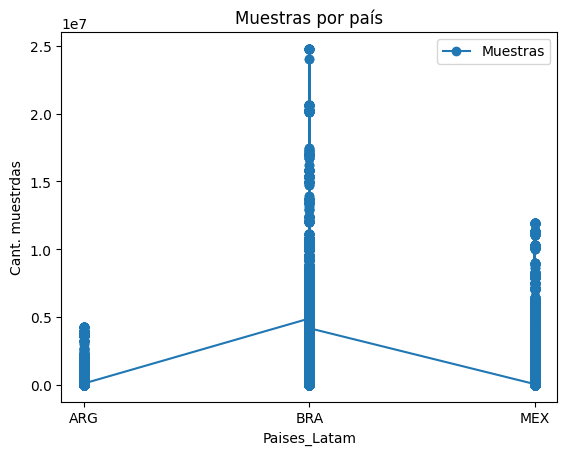

In [839]:
# Mostar la distribución de las muestras por pais

fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.
ax.plot(df['isoalpha3'], df['sample'], marker='o',label='Muestras') # Establecer las coordenadas del grafico de lineas

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Muestras por país") # Titutlo
plt.ylabel("Cant. muestrdas") # Etiqueta del eje x
plt.xlabel("Paises_Latam") # Etiqueta del eje y
ax.legend() # agrega la leyenda "label"


plt.show() # muestra el objeto visual

In [840]:
# ¿Es representativo el gráfico, cómo podemos mejorarlo?
# Agrupar muestras por paises

# Agrupar datos #
#++++++++++++++++

# import warnings
# Ignorar todos los FutureWarning
# warnings.filterwarnings("ignore", category=FutureWarning)

g_df = df.groupby(['isoalpha3']).sum().reset_index()
g_df


,isoalpha3,sample
0,ARG,2.131253e+09
1,BRA,4.957342e+10
2,MEX,2.215370e+10


In [841]:


# Definir las variables que vamos a representar
df2=g_df[['isoalpha3','sample']]
print(df2)


  isoalpha3        sample
0       ARG  2.131253e+09
1       BRA  4.957342e+10
2       MEX  2.215370e+10


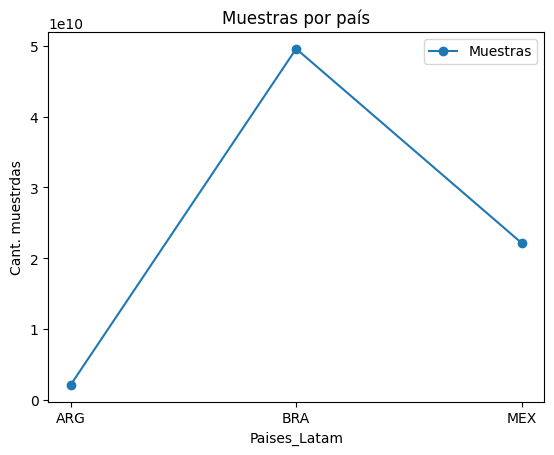

In [842]:
# Mostar la distribución de las muestras por pais

fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.
ax.plot(df2['isoalpha3'], df2['sample'], marker='o',label='Muestras') # Establecer las coordenadas del grafico de lineas

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Muestras por país") # Titutlo
plt.ylabel("Cant. muestrdas") # Etiqueta del eje x
plt.xlabel("Paises_Latam") # Etiqueta del eje y
ax.legend() # agrega la leyenda "label"


plt.show() # muestra el objeto visual

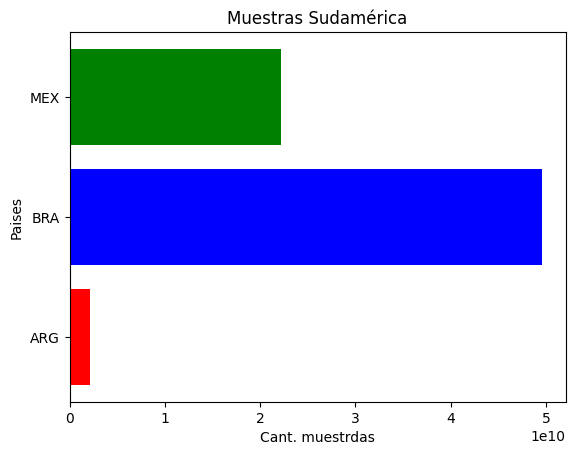

In [843]:
#2. Gráfico de barras
#++++++++++++++++++++

# Crear un grafico de barras que muestre la cantidad de muestras por paises 
# Mostar la distribución de las muestras por pais

fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.
colores=['red','blue','green'] # Crear una lista de colores
ax.barh(df2['isoalpha3'], df2['sample'],color=colores) # Establecer las coordenadas del grafico de barras horizontales

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Muestras Sudamérica") # Titutlo
plt.xlabel("Cant. muestrdas") # Etiqueta del eje x
plt.ylabel("Paises") # Etiqueta del eje y


plt.show() # muestra el objeto visual

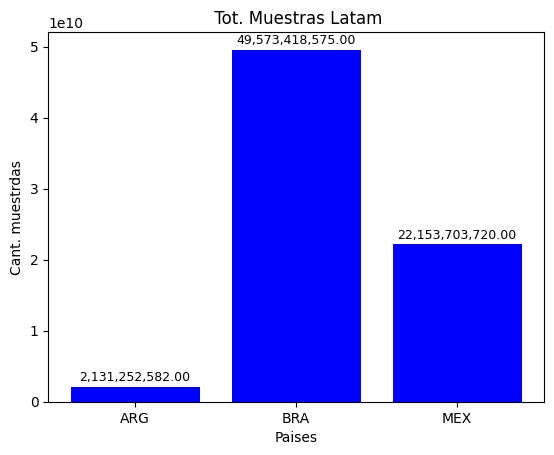

In [1141]:
#2b. Gráfico de barras vertical
#+++++++++++++++++++++++++++++

fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.
bars=ax.bar(df2['isoalpha3'], df2['sample'],color='blue') # Establecer las coordenadas del grafico de barras horizontales

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title(" Tot. Muestras Latam") # Titutlo
plt.ylabel("Cant. muestrdas") # Etiqueta del eje x
plt.xlabel("Paises") # Etiqueta del eje y

# Agregar etiquetas numéricas encima de cada barra
ax.bar_label(bars, labels=[f'{v:,.2f}' for v in df2['sample']], padding=2, fontsize=9)

# labels= crea una lista de strings con formato numérico, usando coma como separador de miles y dos decimales.
# padding=3: distancia entre la etiqueta y la barra.
# fontsize=9: tamaño de fuente de las etiquetas.

plt.show() # muestra el objeto visual

In [1142]:
#3. Grafico de dispersión
#++++++++++++++++++++++++

# Muestra el grado de asociación, relación, o correlación entre dos variables numéricas.
# Determinar cual es el grado de asociación entre los años y la cantidad de muestras recolectadas en todos los países de latam.

In [1143]:
# Agrupar muestras por años
df3=t5[['year','sample']]
df3

,year,sample
0,2001,66484.0
1,2001,91575.0
2,1970,121099.0
3,1970,466827.0
4,1970,121100.0
...,...,...
279224,2001,1155815.0
279225,2001,120562.0
279226,2001,120562.0
279227,2001,1035253.0


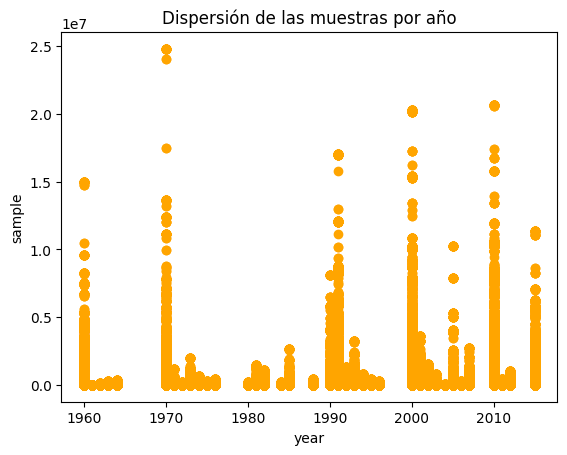

In [1144]:


fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.

ax.scatter(df3['year'], df3['sample'],color='orange') # Establecer las coordenadas del grafico de dispersión

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Dispersión de las muestras por año") # Titutlo
plt.ylabel("sample") # Etiqueta del eje x
plt.xlabel("year") # Etiqueta del eje y


plt.show() # muestra el objeto visual

In [1145]:
# # ¿Cómo podemos mejorar el gráfico?

# Por ej. podríamos agrupar las muestras por año

g_df3 = t5.groupby([ 'year']).sum().reset_index()
g_df3[['year','sample']].head(10)


,year,sample
0,1960,7.521968e+09
1,1961,1.710555e+06
2,1962,4.999546e+07
3,1963,7.639760e+07
4,1964,5.561337e+07
5,1970,6.591579e+09
6,1971,1.496733e+08
7,1972,5.273616e+07
8,1973,5.950085e+08
9,1974,1.034614e+08


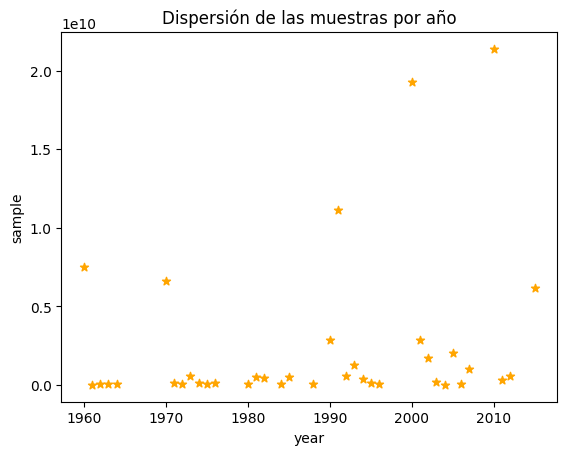

In [1146]:
# Grafico de dispersión de datos agrupados

fig, ax=plt.subplots() # fig:crea el objeto gráfico, ax:representa los ejes dentro de la figura.

ax.scatter(g_df3['year'], g_df3['sample'],color='orange',marker='*') # Establecer las coordenadas del grafico de dispersión

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Dispersión de las muestras por año") # Titutlo
plt.ylabel("sample") # Etiqueta del eje x
plt.xlabel("year") # Etiqueta del eje y


plt.show() # muestra el objeto visual

In [1147]:
# 4. Grafico de Boxplot
#++++++++++++++++++++++
# El gráfico de caja bigotes muestra la distribución de un conjunto de datos numéricos. Muestrda el valor min. y maximo en los
# extremos de los bigotes, el primer cuartil (Q1), la mediana (Q2), el tercer cuartil (Q3). Q1,Q2 y Q3 representan:
# el 25%,50% y 75% de los datos. Por fuera de los bigotes se muestras los valores atípicos o outliers.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\3099659203.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['isoalpha3'], # grupos , var. categórica.


Text(0.5, 0, 'year')

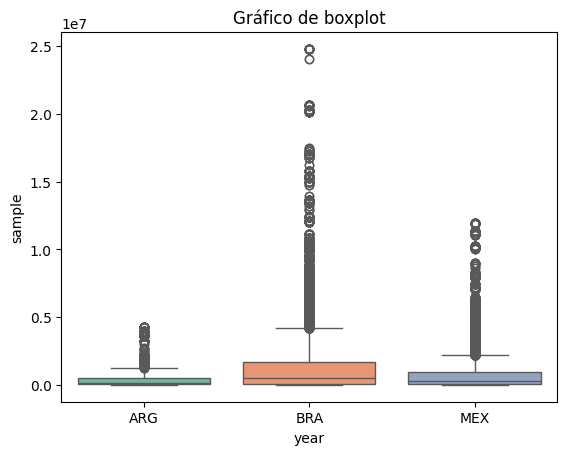

In [1148]:
# Mostrar la distribucion de las muestras por paises seleccioanados.
# En este caso no es conveniente trabajar con datos agrupados, ¿porqué?
import seaborn as sns

# Box plot por grupo
sns.boxplot(x=df['isoalpha3'], # grupos , var. categórica.
            y=df['sample'], # variable numérica. 
            palette='Set2')  # Establecer una paleta de colores

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Gráfico de boxplot") # Titutlo
plt.ylabel("sample") # Etiqueta del eje x
plt.xlabel("year") # Etiqueta del eje y


In [1149]:
# Cómo podemos mejorar la visualización del boxplot?
# podriamos manipular la escala numerica aplicando logaritmos

import seaborn as sns

# Aplicar transformación logarítmica
df['log_sample'] = np.log(df['sample'])
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\1203361028.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_sample'] = np.log(df['sample'])


,isoalpha3,sample,log_sample
0,ARG,66484.0,11.104717
1,ARG,91575.0,11.424914
2,ARG,121099.0,11.704364
3,ARG,466827.0,13.053714
4,ARG,121100.0,11.704372
...,...,...,...
201495,MEX,822638.0,13.620272
201496,MEX,2547.0,7.842671
201497,MEX,2322592.0,14.658194
201498,MEX,2322592.0,14.658194


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\1227475340.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['isoalpha3'], # grupos , var. categórica.


Text(0.5, 0, 'year')

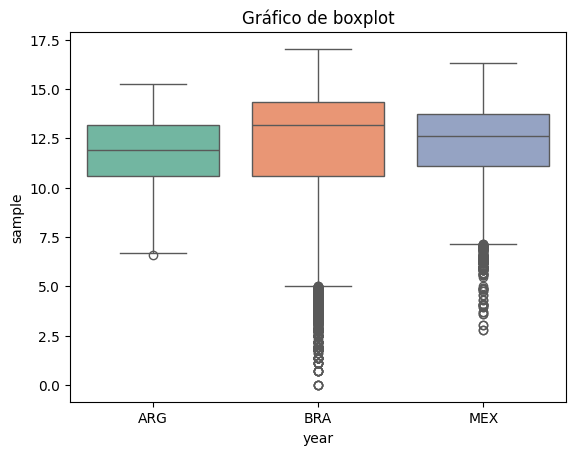

In [1150]:

sns.boxplot(x=df['isoalpha3'], # grupos , var. categórica.
            y=df['log_sample'], # variable numérica. 
            palette='Set2')  # Establecer una paleta de colores

# Titulos, etiquetas de los ejes, leyenda al gráfico.
plt.title("Gráfico de boxplot") # Titutlo
plt.ylabel("sample") # Etiqueta del eje x
plt.xlabel("year") # Etiqueta del eje y

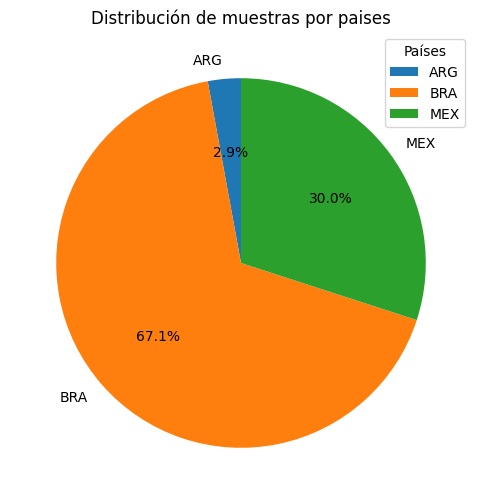

In [1151]:
# Pie chart
#-----------

# Datos agrupados
categorias =df2['isoalpha3'] # paises
valores=df2['sample'] # cant. muestras agrup.

# Crear el gráfico de tortas
plt.figure(figsize=(6, 6),facecolor='white')  # Tamaño y fondo del gráfico
plt.pie(valores, labels=categorias, autopct="%1.1f%%", startangle=90) # Argumentos del grafico

# startangle=90, Rota el gráfico en sentido antihorario. El primer segmento inicia a los 90 grados.

# Agregar leyenda
plt.legend(title="Países", loc="upper right")

# Mostrar el gráfico
plt.title("Distribución de muestras por paises")
plt.show()


In [1152]:
# Manejo de outliers #
######################

Q1=t6['sample'].quantile(0.25)
Q3= t6['sample'].quantile(0.75)
IQR=Q3-Q1

# Metodo de tukey para identificar umbrales thresholds
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR


print(f" Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, LB:{lower_bound}, UP:{upper_bound}")


 Q1: 5518.0, Q3: 138129.0, IQR: 132611.0, LB:-193398.5, UP:337045.5


In [1153]:
# reemplazar 130 datos nulos por un valor arbitrario: -200000
#t2.illiteracy.replace({1.383240:np.nan,2.714140:''},inplace=True)

t6['sample'] = t6['sample'].fillna(-200000)
t6

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\984246641.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t6['sample'] = t6['sample'].fillna(-200000)


,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Outliers
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,Normal
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,Normal
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,Normal
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,Upper_Bound
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,Normal
...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,Upper_Bound
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,Normal
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,Normal
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,Upper_Bound


In [1154]:
# Asignamos la columna de outliers al data frame
t6['Outliers']=''
t6.loc[t6['sample']<lower_bound,'Outliers']='Lower_Bound'
t6.loc[t6['sample']>upper_bound,'Outliers']='Upper_Bound'
t6.loc[(t6['sample']>=lower_bound) & (t6['sample']<=upper_bound),'Outliers']='Normal'
t6

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13808\2871877916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t6['Outliers']=''


,year,isoalpha3,source,area,sex,education_level,age,ethnicity,sample,Outliers
0,2001,ARG,IPUMS,rural,Total,Total,15_24,Total,66484.0,Normal
1,2001,ARG,IPUMS,rural,Total,Total,15_29,Total,91575.0,Normal
2,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121099.0,Normal
3,1970,ARG,IPUMS,Total,Total,Total,Total,Total,466827.0,Upper_Bound
4,1970,ARG,IPUMS,Total,Total,Total,Total,Total,121100.0,Normal
...,...,...,...,...,...,...,...,...,...,...
279224,2001,VEN,IPUMS,Total,women,Total,Total,Total,1155815.0,Upper_Bound
279225,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,Normal
279226,2001,VEN,IPUMS,rural,women,Total,Total,Total,120562.0,Normal
279227,2001,VEN,IPUMS,urban,women,Total,Total,Total,1035253.0,Upper_Bound


In [1155]:

# Contar cuántas categorías únicas hay
num_categorias = t6['Outliers'].value_counts()
print(num_categorias)


Outliers
Normal         235857
Upper_Bound     43242
Lower_Bound       130
Name: count, dtype: int64


In [1156]:
# DICCIONARIOS E PYTHON #
#########################

# Un diccionario en Python es una estructura de datos que permite almacenar y organizar elementos en pares clave-valor.
# Cada elemento del diccionario consiste en una clave única (no se permiten claves duplicadas) y su correspondiente valor asociado. 
# Los diccionarios permiten  mapear y acceder a valores utilizando sus claves en lugar de índices numéricos.
# Tipo de datos: números, cadenas, listas, tuplas e incluso otros diccionarios.
# Longitud de un diccionario: es el número de elementos (pares clave-valor) presentes en el diccionario. 
# Tipo de datos: es un tipo de datos "dict".

persona = {
    "nombre": "Alice",
    "edad": 30,
    "ciudad": "Nueva York"
}

In [1157]:
Cant_Atributos=len(persona)
Tipo_Dato=type(persona)

print(f'Cant_Atributos:{Cant_Atributos}, Tipo_Dato:{Tipo_Dato}')

Cant_Atributos:3, Tipo_Dato:<class 'dict'>


In [1158]:
# Crear un diccionario
Habitante={
    "Nombre": "Maria",
    "Edad": 32,
    "Estudia":True,
    "anio_ingreso":"01-08-2022",
    "Notas_mat":[6,8,9],  # lista de califiaciones
    "Ciudad":"Córdoba"
}

Cant_Atr_2=len(Habitante)
Tipo_Dat_2=type(Habitante)

print(f'Cant_Atributos:{Cant_Atr_2}, Tipo_Dato:{Tipo_Dat_2}')

Cant_Atributos:6, Tipo_Dato:<class 'dict'>


In [1159]:
# Acceder a info. de un diccionario
Edad=Habitante['Edad']
Nombre_p=Habitante['Nombre']

print(f'La edad de {Nombre_p} es:{Edad}')

La edad de Maria es:32


In [1160]:
# Modificar info. de un diccionario
Habitante['Edad']=28
Edad=Habitante['Edad']
print(f'La edad correcta de {Nombre_p} es:{Edad}')

La edad correcta de Maria es:28


In [1161]:
# Agregar un Nuevo atributo
Habitante['Nacionalidad']='argentina'
Habitante

{'Nombre': 'Maria',
 'Edad': 28,
 'Estudia': True,
 'anio_ingreso': '01-08-2022',
 'Notas_mat': [6, 8, 9],
 'Ciudad': 'Córdoba',
 'Nacionalidad': 'argentina'}

In [1162]:
# Eliminar un atributo de un diccionario
del Habitante['Ciudad']

In [1163]:
Habitante

{'Nombre': 'Maria',
 'Edad': 28,
 'Estudia': True,
 'anio_ingreso': '01-08-2022',
 'Notas_mat': [6, 8, 9],
 'Nacionalidad': 'argentina'}

In [1164]:
# Crear un Diccionario Anidado
# los diccionarios pueden contener otros diccionarios dentro de ellos creando estructuras anidadas.
diccionario_anidado = {
    'persona1': {   
        'nombre': 'Alice',
        'edad': 25
    },

    'persona2': {
        'nombre': 'Bob',
        'edad': 30,
        'Ciudad':'LA'
    }
}

In [1165]:
diccionario_anidado

{'persona1': {'nombre': 'Alice', 'edad': 25},
 'persona2': {'nombre': 'Bob', 'edad': 30, 'Ciudad': 'LA'}}

In [1166]:
diccionario_anidado['persona1']['nombre']

'Alice'

In [1167]:
# Agregar un Diccionario Anidado
diccionario_anidado['persona3']= {
                     'nombre':'Peter',
                     'edad': 27
                        }

In [1168]:
diccionario_anidado

{'persona1': {'nombre': 'Alice', 'edad': 25},
 'persona2': {'nombre': 'Bob', 'edad': 30, 'Ciudad': 'LA'},
 'persona3': {'nombre': 'Peter', 'edad': 27}}

In [1169]:
# Agregar elementos en un diccionario anidado
diccionario_anidado['persona3']['idioma']='EN'
diccionario_anidado

{'persona1': {'nombre': 'Alice', 'edad': 25},
 'persona2': {'nombre': 'Bob', 'edad': 30, 'Ciudad': 'LA'},
 'persona3': {'nombre': 'Peter', 'edad': 27, 'idioma': 'EN'}}

In [1170]:
# Modificar datos de un diccionario anidado
diccionario_anidado['persona3']['nombre']='Robert'
diccionario_anidado

{'persona1': {'nombre': 'Alice', 'edad': 25},
 'persona2': {'nombre': 'Bob', 'edad': 30, 'Ciudad': 'LA'},
 'persona3': {'nombre': 'Robert', 'edad': 27, 'idioma': 'EN'}}

In [1171]:
# Eliminar un diccionario anidado
del diccionario_anidado['persona1']

In [1172]:
diccionario_anidado

{'persona2': {'nombre': 'Bob', 'edad': 30, 'Ciudad': 'LA'},
 'persona3': {'nombre': 'Robert', 'edad': 27, 'idioma': 'EN'}}